# `rasterEngine` - The geospatial processing engine for raster data

In this tutorial we will explor the functionality contained with the top most layer of the software architecture hierarchy of the `bmc` library. `baseGrid` serves as the foundation of all geospatial processing as it contains the groundtruth to which all transformations, mappings and sampling will be performed to. The class serves as the parent class for both the `rasterEngine` and `vectorEngine` leading to a further specialization of processing geospatial data. A UML diagram of the top layer is displayed below

In this tutorial we will explore the functionality contained within the `rasterEngine` at the second level of the software architecture hierarchy. This engine inherits directly from `baseGrid` and has a child `rasterCube`. 

```mermaid
classDiagram
    direction TB

    class baseGrid {
        <<Parent>>
        +dict GRID_REGISTRY
        +resolve_grid_registry_key()
        +build_safe_fetch_envelope()
        +create_aligned_raster_template()
        +calculate_deterministic_global_indices()
    }

    class rasterEngine {
        <<Core Engine>>
        +dict GDAL_RESAMPLERS
        +dict RESAMPLER_DECODER
        +_parse_res_to_meters()
        +_resolve_query_resolution()
        +_sanitize_spatial_geometry()
        +affine_reproject()
        +compute_class_fraction()
    }

    class rasterCube {
        <<High-Level Orchestrator>>
        +resolve_target_grid()
        +generate_execution_plan()
        +parse_metadata()
        +get_resample_rule()
        +generate_raster_stac_item()
        +process_cube()
    }

    %% Inheritance relationships
    baseGrid <|-- rasterEngine : Inherits
    rasterEngine <|-- rasterCube : Inherits

The class serves a central hub to aggregate all geospatial methods that are needed to perform harmonization of raster data. Crucially, it is completely decoupled from data lifecycle management (like downloading or cataloging), focusing exclusively on the physical transformation of arrays. By leveraging out-of-core GDAL C++ wrappings, the engine safely executes heavy operations like affine reprojections and continuous fractional area calculations on massive datasets without exceeding memory limits. It also acts as the gatekeeper for ecological validity, enforcing mathematically appropriate resampling algorithms depending on whether the incoming raster is continuous or categorical.

# Attributes of the Spatial engine

## Resampling strategy

The `rasterEngine` class serves as the mathematical framework that drives the resampling and reprojection of geospatial data to a harmonized data product. The underlying library that drives the math is the GDAL library, and as such we are restricted to the available resamplers defined within

In [2]:
from bmc.engine.raster import rasterEngine

engine = rasterEngine()

print("Available GDAL Resamplers in the Engine:")
# GDAL_RESAMPLERS maps human-readable strings to GDAL C++ integer constants
for resampler_key, gdal_int in engine.GDAL_RESAMPLERS.items():
    print(f" - {resampler_key} (GDAL ID: {gdal_int})")

Available GDAL Resamplers in the Engine:
 - nearestNeighbour (GDAL ID: 0)
 - bilinear (GDAL ID: 1)
 - cubic (GDAL ID: 2)
 - cubicSpline (GDAL ID: 3)
 - lanczos (GDAL ID: 4)
 - average (GDAL ID: 5)
 - mode (GDAL ID: 6)
 - max (GDAL ID: 8)
 - min (GDAL ID: 9)
 - med (GDAL ID: 10)
 - q1 (GDAL ID: 11)
 - q3 (GDAL ID: 12)
 - sum (GDAL ID: 13)
 - rms (GDAL ID: 14)


### Categorical & Discrete Data
Use these for data like Land Cover or Forest Types to avoid creating decimal values that don't represent real categories:

* **nearestNeighbour**: Assigns the value of the single closest source pixel, preserving original discrete values without interpolation.
* **mode**: Assigns the most frequently occurring value among contributing pixels. The mathematical standard for downsampling categorical data.

---

### Continuous Data Smoothing
Use these for interpolating continuous gradients like Elevation or Temperature:

* **bilinear**: Distance-weighted average of the 4 closest source pixels.
* **cubic**: Distance-weighted cubic polynomial curve over the 16 nearest pixels.
* **cubicSpline**: 2D B-spline mathematical function over the 16 nearest pixels. Heavily smooths data and prevents "overshoot" (Runge's phenomenon). The gold standard for realistic, continuous gradients.
* **lanczos**: Complex windowed sinc function over the 36 nearest source pixels. Preserves high-frequency details and sharpness.

---

### Continuous Data Statistical Aggregation (Downsampling)
Use these when aggregating high-resolution continuous data into larger target grid cells:

* **average**: Arithmetic mean of all valid intersecting source pixels.
* **max / min**: Highest or lowest data value within the target footprint.
* **med**: Exact middle value (50th percentile) of contributing pixels.
* **q1 / q3**: First (25th) or third (75th) quartile of contributing pixels.
* **sum**: Addition of all valid intersecting source pixels.
* **rms**: Root Mean Square (quadratic mean). Emphasizes higher magnitude values.

# Methods of the `rasterEngine`

## Utility functions in geospatial processing

### Sanitizing Spatial Geometry (`_sanitize_spatial_geometry`)

When transitioning data between the lazy, Python-based `xarray` ecosystem and the highly rigid C++ `GDAL` warping engines, metadata and coordinate arrays often get mistranslated or rejected. 

The `_sanitize_spatial_geometry` acts as a crucial pre-flight checklist to ensure GDAL will accept the data without crashing. It performs four essential cleaning steps:

1. **Standardizes Axes:** Climate and weather NetCDFs often use `lon`, `longitude`, `lat`, or `latitude`. GDAL/rioxarray strongly prefers standardized `x` and `y` spatial dimensions.
2. **Enforces a CRS:** If a loaded array is missing its Coordinate Reference System, the engine injects a safe fallback (defaulting to EPSG:4326) to prevent spatial warping failures.
3. **Clears Dimension Encoding:** `xarray` holds onto the original file's disk encoding (chunk sizes, offsets, fill values). If the data is manipulated in memory and then saved, old encodings can corrupt the new file. This function strips that baggage.
4. **Erases Microscopic Floating-Point Drift:** Python floating-point math can sometimes introduce microscopic errors in coordinate spacing (e.g., a pixel size of `10.00000000001` instead of `10.0`). GDAL's strict C++ kernel detects this as an "irregular grid" and will throw a fatal error. Generating a fresh `np.linspace` between the min and max bounds mathematically guarantees perfect pixel spacing.

## Geospatial processing functionality

## Aligning Data with `affine_reproject`

Now that we have covered how to define our foundational grids, we need to mathematically align raw incoming data to those master grids. The `affine_reproject` method is the core engine for this transformation. 

This method is built for scale and precision. Rather than performing spatial transformations entirely in-memory—which risks Out-Of-Memory (OOM) crashes when handling massive datasets—it safely routes lazy `xarray` objects to a temporary disk stream and invokes highly optimized **GDAL C++** bindings for the heavy lifting. 

Crucially, it guarantees perfect **Grid Snapping**. When projecting data from one Coordinate Reference System (CRS) to another, it calculates the newly transformed boundaries and mathematically forces the output to expand outward. This ensures the resulting edges land precisely on the predefined, integer-aligned pixel boundaries of the target master grid. 

To demonstrate this out-of-core transformation and strict alignment, we will:
1. Generate a mock `xarray` dataset representing continuous data (like temperature) in a standard WGS84 (EPSG:4326) projection.
2. Run `affine_reproject` to warp and snap this data to our metric European `EEA_1km` grid, utilizing the appropriate `bilinear` resampling algorithm from our registry.
3. Inspect the resulting dataset to verify that its spatial coordinates have been perfectly snapped to the 1km intervals of our master grid.

### Generating dummy data

In [4]:
import numpy as np
import xarray as xr
import rioxarray

def generate_dummy_raster(bounds, resolution, crs="EPSG:4326"):
    """
    Creates a synthetic continuous gradient raster (e.g., mock temperature) for testing.
    """
    minx, miny, maxx, maxy = bounds
    
    # Generate coordinate arrays based on the requested resolution
    x_coords = np.arange(minx, maxx, resolution)
    y_coords = np.arange(maxy, miny, -resolution)
    X, Y = np.meshgrid(x_coords, y_coords)
    
    # Create a simple geographic gradient pattern using sine/cosine waves
    data = np.sin(X * 5) + np.cos(Y * 5)
    
    # Build the xarray DataArray
    da = xr.DataArray(
        data.astype(np.float32), 
        coords=[("y", y_coords), ("x", x_coords)],
        dims=["y", "x"]
    )
    
    # Inject CF-compliant spatial topology via rioxarray
    da = da.rio.write_crs(crs)
    da = da.rio.write_nodata(np.nan)
    
    return da

# 2. Define a mock WGS84 bounding box over a region in Europe (Longitude / Latitude)
wgs84_bounds = (4.0, 50.0, 5.0, 51.0) # (min_lon, min_lat, max_lon, max_lat)

# 3. Fetch the exact native resolution of our WGS84 source from the registry
wgs_res = engine.GRID_REGISTRY["Global_WGS84_30sec"]["resolution"]

# 4. Generate the mock source dataset
source_da = generate_dummy_raster(wgs84_bounds, wgs_res)

print("--- Mock Source Dataset Generated ---")
print(f"Shape: {source_da.shape}")
print(f"CRS:   {source_da.rio.crs}")
print(f"X Min: {float(source_da.x.min()):.4f} | X Max: {float(source_da.x.max()):.4f}")
print(f"Y Min: {float(source_da.y.min()):.4f} | Y Max: {float(source_da.y.max()):.4f}")

--- Mock Source Dataset Generated ---
Shape: (120, 120)
CRS:   EPSG:4326
X Min: 4.0000 | X Max: 4.9917
Y Min: 50.0083 | Y Max: 51.0000


### Executing the Reprojection

In [5]:
import os

# Create a dummy output directory for our tutorial artifacts
os.makedirs("test_engine_outputs", exist_ok=True)
target_grid = "EEA_1km"

print(f"Initiating out-of-core reprojection to {target_grid}...")

# Warp the continuous mock dataset using bilinear resampling
warped_da = engine.affine_reproject(
    input_data=source_da,
    output_filepath="test_engine_outputs/warped_eea_1km.tif",
    grid_name=target_grid,
    resample_keyword="bilinear"
)

print("\n--- Reprojection & Grid Snapping Complete ---")
print(f"New CRS: {warped_da.rio.crs}")
print(f"Shape:   {warped_da.shape}")

# Verify the Grid Snapping Math
# The edges should perfectly divide by the 1000m resolution with zero remainder
minx, miny, maxx, maxy = warped_da.rio.bounds()
res = engine.GRID_REGISTRY[target_grid]["resolution"]

print(f"\n--- Snapping Verification ---")
print(f"Snapped X Min: {minx} (Modulo {res}: {minx % res})")
print(f"Snapped Y Max: {maxy} (Modulo {res}: {maxy % res})")

Initiating out-of-core reprojection to EEA_1km...
Preparing out-of-core reprojection to EEA_1km...
Utilizing 'bilinear' resampling for reprojection.
Lazy xarray object detected. Preparing for disk stream...
Sanitizing spatial geometry...
Warping to test_engine_outputs/warped_eea_1km.tif (Resampling: bilinear)...
Reprojection complete.

--- Reprojection & Grid Snapping Complete ---
New CRS: EPSG:3035
Shape:   (1, 117, 80)

--- Snapping Verification ---
Snapped X Min: 3891000.0 (Modulo 1000: 0.0)
Snapped Y Max: 3117000.0 (Modulo 1000: 0.0)


### Visualizing the Pipeline & The NoData Trap

To truly understand the explicit warping that happens under the hood—and to avoid a classic remote sensing trap—we must look at the data before and after the GDAL C++ reprojection.

When taking a dataset from a geographic globe (WGS84) and flattening it into a localized metric projection (EPSG:3035), the data is physically rotated, stretched, and resampled. 

1. **Native Source (EPSG:4326):** On a geographic map, our data sits on a flat grid of degrees. But in physical reality, this box is curved and slanted.
2. **Warped Master Grid (EPSG:3035):** When the engine reprojects the data into our flat metric grid, it physically rotates the pixels. Because rasters must remain perfect rectangles, this rotation leaves empty triangles at the corners of the bounding box.
3. **The NoData Trap:** GDAL does not automatically write `NaN` to these empty corners; it writes a specific mathematical NoData value (often `-9999.0` or similar). If you don't explicitly mask this out before doing math, standard operations (like means or sums) will treat the empty space as valid data and silently ruin your analysis!

Let's visualize this rotation and properly mask our NoData values.

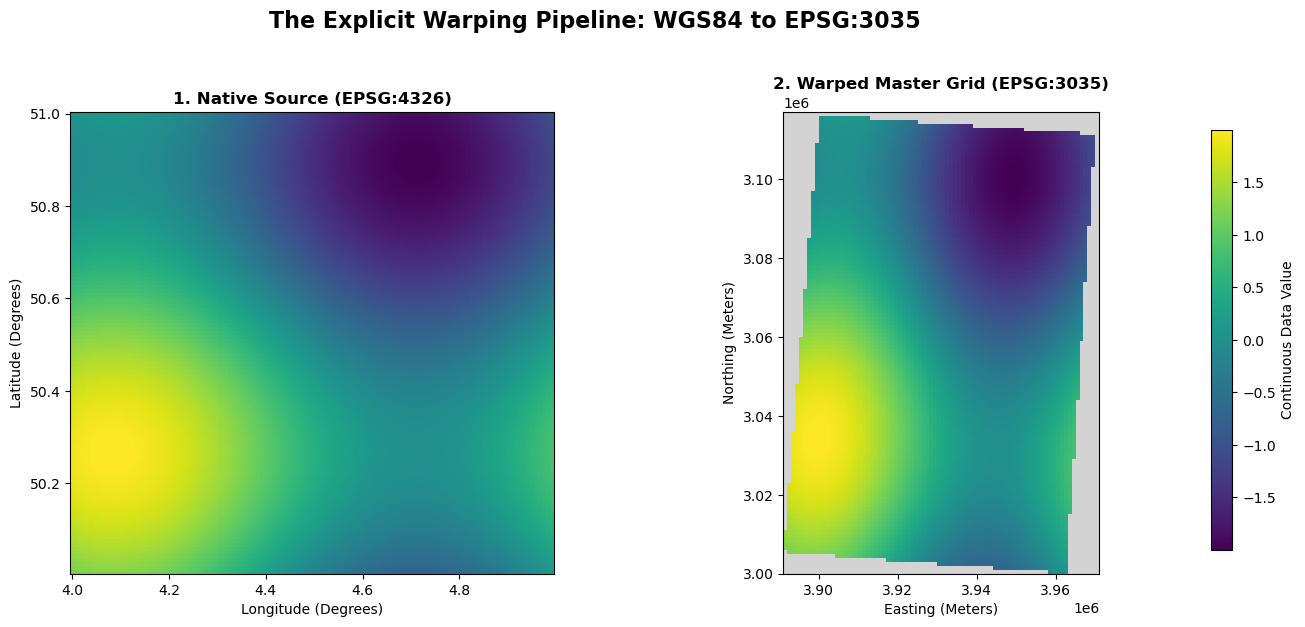

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Fix the NoData calculation ---
# Fetch the NoData value assigned by GDAL during the warp
nodata_val = warped_da.rio.nodata

# Explicitly mask out the NoData values so they don't skew our statistics or plots
if nodata_val is not None:
    missing_mask = np.logical_or(np.isnan(warped_da), warped_da == nodata_val)
else:
    missing_mask = np.isnan(warped_da)

# Apply the mask for plotting (makes NoData transparent instead of a solid color)
warped_plot_da = warped_da.where(~missing_mask)


# --- 2. Set up the 2-Panel Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.suptitle("The Explicit Warping Pipeline: WGS84 to EPSG:3035", fontsize=16, fontweight='bold', y=1.05)

# Lock the color scale so the stretching/warping effect is obvious across both plots
vmin = float(source_da.min())
vmax = float(source_da.max())

# --- PANEL 1: Original Data in WGS84 ---
source_da.plot(ax=axes[0], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax)

axes[0].set_title("1. Native Source (EPSG:4326)", fontweight='bold')
axes[0].set_aspect('auto')
axes[0].set_xlabel("Longitude (Degrees)")
axes[0].set_ylabel("Latitude (Degrees)")


# --- PANEL 2: Warped Reprojection (EPSG:3035) ---
im = warped_plot_da.plot(ax=axes[1], add_colorbar=False, cmap='viridis', vmin=vmin, vmax=vmax)

axes[1].set_title("2. Warped Master Grid (EPSG:3035)", fontweight='bold')
# Setting a gray background makes the masked NoData corners instantly obvious
axes[1].set_facecolor('lightgray') 
axes[1].set_aspect('equal')
axes[1].set_xlabel("Easting (Meters)")
axes[1].set_ylabel("Northing (Meters)")


# --- Clean up formatting ---
fig.subplots_adjust(right=0.92, wspace=0.3)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Continuous Data Value")

plt.show()

# Clean up memory/locks
warped_da.close()

## Handling Categorical Data: Class Fractions

## Handling Categorical Data: Class Fractions

When harmonizing continuous data, resampling algorithms like `bilinear` or `average` work perfectly. However, **categorical data** (where pixel values represent discrete, independent categories like Class A, Class B, or Class C) presents a major challenge. 

If we downsample a high-resolution discrete map to a coarser master grid using `nearestNeighbour` or `mode`, minority classes completely disappear. For example, if a coarse target pixel covers an area that is composed of 60% Class A and 40% Class B, a `mode` resampler will label the entire pixel as "100% Class A", completely destroying the data for Class B.

To solve this, the `rasterEngine` provides the `compute_class_fraction` method. Instead of trying to preserve the discrete categories during a direct downsample, this pure spatial math primitive isolates a single target class, converts it into a binary mask (1 for the target, 0 for everything else), and mathematically computes its fractional coverage (0.0 to 1.0) using an `average` resample.

In [12]:
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def generate_noisy_categorical_raster(bounds, resolution, crs="EPSG:4326"):
    """
    Creates a synthetic, noisy high-resolution categorical raster.
    1 = Class A, 2 = Class B, 3 = Class C
    """
    minx, miny, maxx, maxy = bounds
    x_coords = np.arange(minx, maxx, resolution)
    y_coords = np.arange(maxy, miny, -resolution)
    X, Y = np.meshgrid(x_coords, y_coords)
    
    # Generate distinct blobs using sine waves
    base_pattern = np.sin(X * 15) + np.cos(Y * 15)
    
    # Inject Gaussian noise to create realistic spatial mixing!
    noise = np.random.normal(loc=0.0, scale=1.2, size=X.shape)
    noisy_pattern = base_pattern + noise
    
    # Classify into 3 discrete categories based on the noisy gradient
    data = np.ones_like(noisy_pattern) # Default to 1 (Class A)
    data[noisy_pattern > 0.8] = 2      # 2 (Class B)
    data[noisy_pattern < -0.8] = 3     # 3 (Class C)
    
    da = xr.DataArray(
        data.astype(np.float32), 
        coords=[("y", y_coords), ("x", x_coords)],
        dims=["y", "x"]
    )
    da = da.rio.write_crs(crs)
    da = da.rio.write_nodata(-9999.0)
    return da

# Generate a HIGH-RESOLUTION noisy mock source (e.g., 3-second WGS84, roughly 90m)
high_res = engine.GRID_REGISTRY["Global_WGS84_3sec"]["resolution"]
categorical_source_da = generate_noisy_categorical_raster(wgs84_bounds, high_res)


Calculating fractional coverage for Class A (1)...
Processing small DataArray for class 1 in RAM...
Preparing out-of-core reprojection to EEA_1km...
Utilizing 'average' resampling for reprojection.
Lazy xarray object detected. Preparing for disk stream...
Sanitizing spatial geometry...
Warping to test_engine_outputs/class_A_fraction_1km.tif (Resampling: average)...
Reprojection complete.
Calculating fractional coverage for Class C (3)...
Processing small DataArray for class 3 in RAM...
Preparing out-of-core reprojection to EEA_1km...
Utilizing 'average' resampling for reprojection.
Lazy xarray object detected. Preparing for disk stream...
Sanitizing spatial geometry...
Warping to test_engine_outputs/class_C_fraction_1km.tif (Resampling: average)...
Reprojection complete.


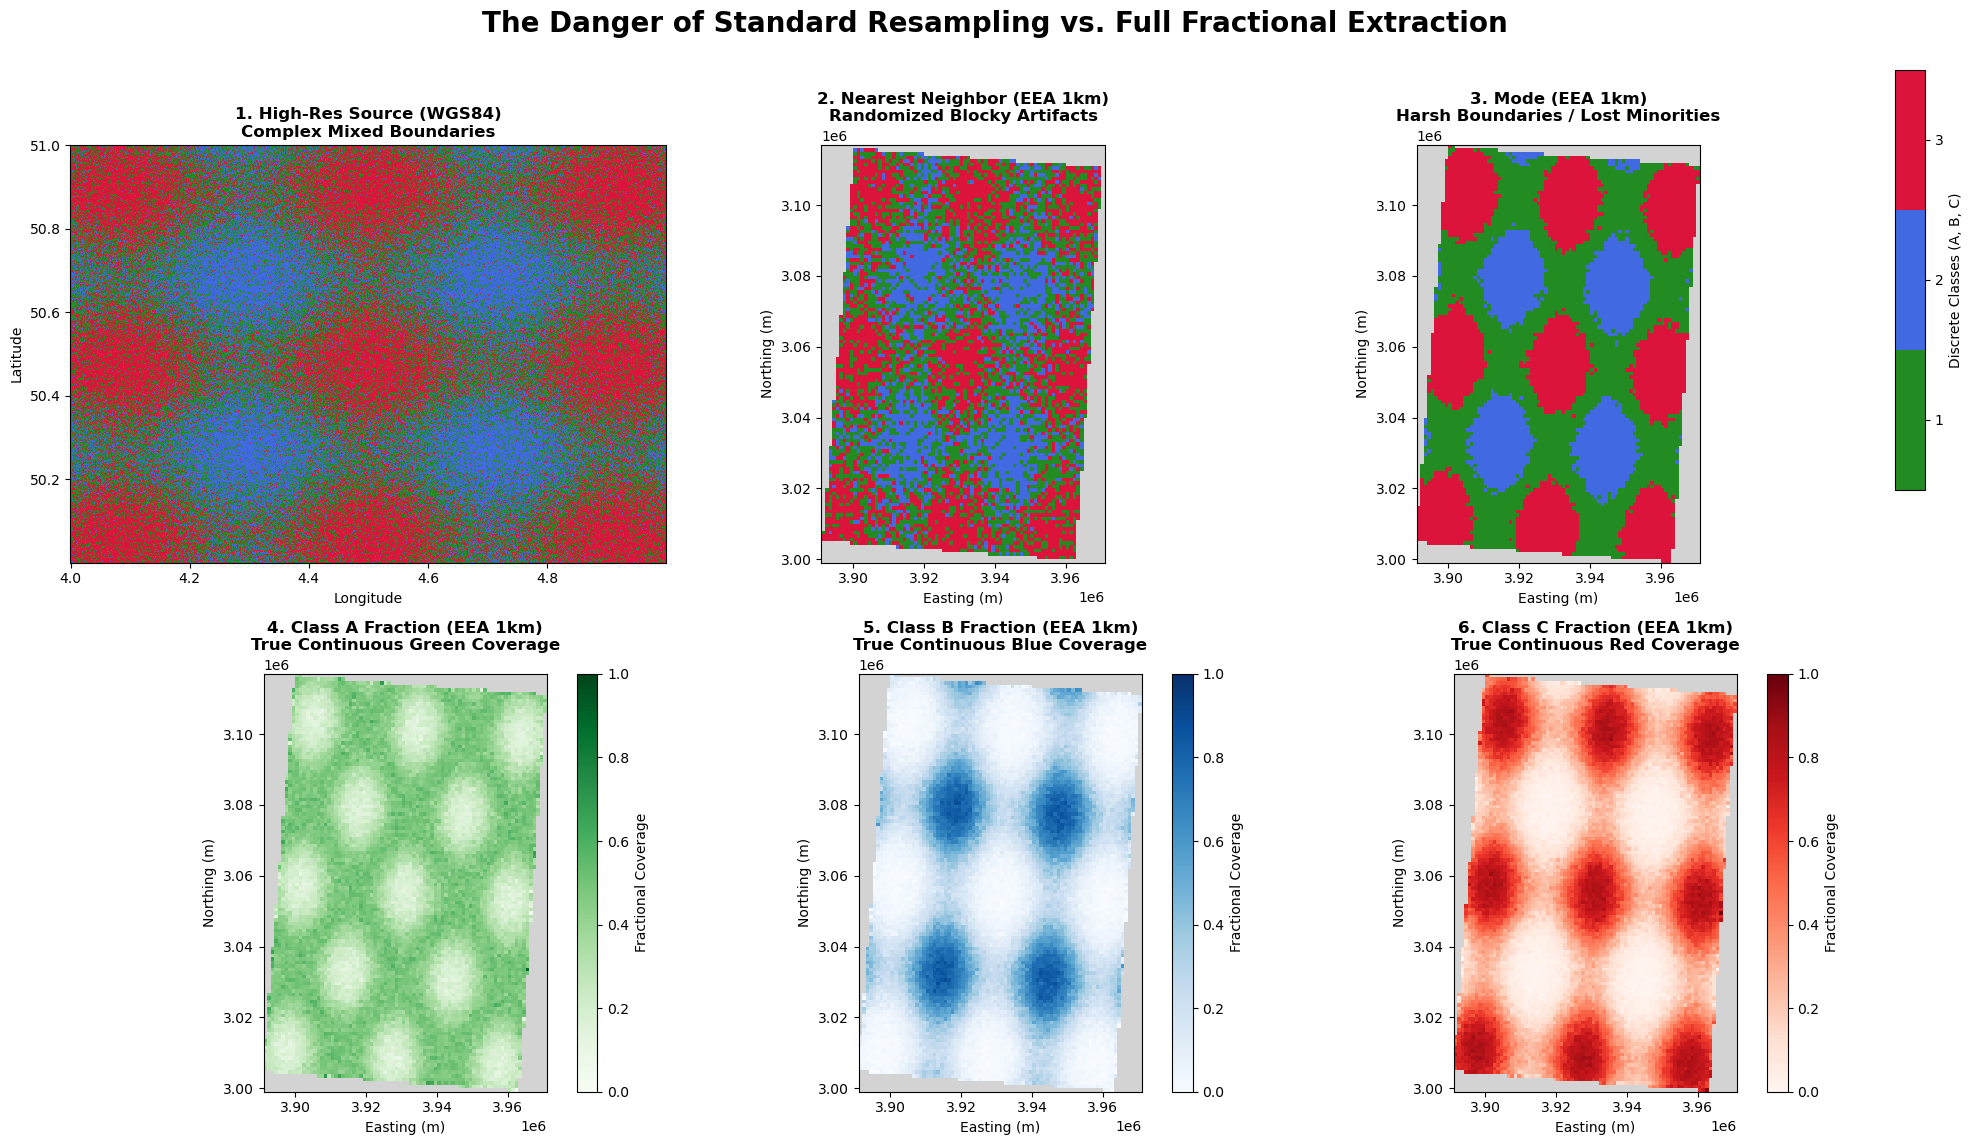

In [13]:
# --- 1. Compute Fractional Coverage for the Remaining Classes ---

# Class A (Value = 1)
print("Calculating fractional coverage for Class A (1)...")
engine.compute_class_fraction(
    source_data=categorical_source_da,
    class_value=1,
    grid_name=target_grid,
    output_filepath="test_engine_outputs/class_A_fraction_1km.tif"
)

# Class C (Value = 3)
print("Calculating fractional coverage for Class C (3)...")
engine.compute_class_fraction(
    source_data=categorical_source_da,
    class_value=3,
    grid_name=target_grid,
    output_filepath="test_engine_outputs/class_C_fraction_1km.tif"
)

# --- 2. Load the New Fractional Data ---
fraction_A_da = rioxarray.open_rasterio("test_engine_outputs/class_A_fraction_1km.tif").squeeze()
fraction_A_da = fraction_A_da.where(fraction_A_da != fraction_A_da.rio.nodata)

fraction_C_da = rioxarray.open_rasterio("test_engine_outputs/class_C_fraction_1km.tif").squeeze()
fraction_C_da = fraction_C_da.where(fraction_C_da != fraction_C_da.rio.nodata)


# --- 3. Plot the 2x3 Master Comparison ---
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
plt.suptitle("The Danger of Standard Resampling vs. Full Fractional Extraction", fontsize=20, fontweight='bold', y=0.95)

# ==========================================
# ROW 1: The Categorical Challenge
# ==========================================
# Panel 1: High-Res Source
categorical_source_da.plot(ax=axes[0, 0], add_colorbar=False, cmap=cmap_cat, vmin=0.5, vmax=3.5)
axes[0, 0].set_title("1. High-Res Source (WGS84)\nComplex Mixed Boundaries", fontweight='bold')
axes[0, 0].set_aspect('auto')

# Panel 2: Nearest Neighbor
nearest_da.plot(ax=axes[0, 1], add_colorbar=False, cmap=cmap_cat, vmin=0.5, vmax=3.5)
axes[0, 1].set_title("2. Nearest Neighbor (EEA 1km)\nRandomized Blocky Artifacts", fontweight='bold')
axes[0, 1].set_facecolor('lightgray')
axes[0, 1].set_aspect('equal')

# Panel 3: Mode 
im_cat = mode_da.plot(ax=axes[0, 2], add_colorbar=False, cmap=cmap_cat, vmin=0.5, vmax=3.5)
axes[0, 2].set_title("3. Mode (EEA 1km)\nHarsh Boundaries / Lost Minorities", fontweight='bold')
axes[0, 2].set_facecolor('lightgray')
axes[0, 2].set_aspect('equal')

# ==========================================
# ROW 2: The Fractional Solution
# ==========================================
# Panel 4: Class A (Green)
fraction_A_da.plot(ax=axes[1, 0], add_colorbar=True, cmap='Greens', vmin=0, vmax=1, 
                   cbar_kwargs={'label': 'Fractional Coverage'})
axes[1, 0].set_title("4. Class A Fraction (EEA 1km)\nTrue Continuous Green Coverage", fontweight='bold')
axes[1, 0].set_facecolor('lightgray')
axes[1, 0].set_aspect('equal')

# Panel 5: Class B (Blue)
fraction_da.plot(ax=axes[1, 1], add_colorbar=True, cmap='Blues', vmin=0, vmax=1, 
                 cbar_kwargs={'label': 'Fractional Coverage'})
axes[1, 1].set_title("5. Class B Fraction (EEA 1km)\nTrue Continuous Blue Coverage", fontweight='bold')
axes[1, 1].set_facecolor('lightgray')
axes[1, 1].set_aspect('equal')

# Panel 6: Class C (Red)
fraction_C_da.plot(ax=axes[1, 2], add_colorbar=True, cmap='Reds', vmin=0, vmax=1, 
                   cbar_kwargs={'label': 'Fractional Coverage'})
axes[1, 2].set_title("6. Class C Fraction (EEA 1km)\nTrue Continuous Red Coverage", fontweight='bold')
axes[1, 2].set_facecolor('lightgray')
axes[1, 2].set_aspect('equal')

# --- Shared Formatting ---
for ax in axes.flat:
    # Set labels based on projection type
    ax.set_xlabel("Easting (m)" if ax != axes[0, 0] else "Longitude")
    ax.set_ylabel("Northing (m)" if ax != axes[0, 0] else "Latitude")

# Adjust spacing so colorbars don't overlap
plt.tight_layout(rect=[0, 0, 0.94, 0.93]) 

# Add the categorical colorbar explicitly for Row 1
cbar_cat_ax = fig.add_axes([0.95, 0.55, 0.015, 0.35])
fig.colorbar(im_cat, cax=cbar_cat_ax, label="Discrete Classes (A, B, C)", ticks=[1, 2, 3])

plt.show()

# Clean up memory
fraction_A_da.close()
fraction_C_da.close()